In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# EDA

In [22]:
data = pd.read_csv('obes.csv')
print(f"Total dataset {data.shape[0]} baris dan {data.shape[1]} kolom.")
data.head()

Total dataset 2182 baris dan 17 kolom.


,Gender,Age,Height (m),Weight (kg),Family history of overweight,High caloric food consumption,Vegetable consumption frequency,Daily main meals frequency,Between-meal food consumption frequency,Smoking,Alcohol intake,Daily water intake,Monitor calories,Physical exercise,Daily device usage duration,Mode of transportation,Obesity level
0,Male,29,1.65,101.0,Yes,Yes,Sometimes,Three,Frequently,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Private Car,Obesity_Type_II
1,Female,25,1.65,53.0,No,No,Always,Three,Always,No,I do not drink,Between 1 and 2 L,No,Almost Everyday,More than 5 hours,Public Transportation,Normal_Weight
2,Male,23,1.70,70.0,No,No,Always,Between 1-2,Sometimes,Yes,Sometimes,Less than a liter,No,I do not have,More than 5 hours,Public Transportation,Normal_Weight
3,Male,22,1.68,112.0,Yes,Yes,Sometimes,Three,Frequently,No,I do not drink,Between 1 and 2 L,No,I do not have,More than 5 hours,Public Transportation,Obesity_Type_II
4,Male,19,1.75,67.0,No,Yes,Always,Three,Sometimes,Yes,I do not drink,Between 1 and 2 L,No,2 or 4 days,3-5 hours,Bike,Normal_Weight


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   2182 non-null   object 
 1   Age                                      2182 non-null   int64  
 2   Height (m)                               2182 non-null   float64
 3   Weight (kg)                              2182 non-null   float64
 4   Family history of overweight             2182 non-null   object 
 5   High caloric food consumption            2182 non-null   object 
 6   Vegetable consumption frequency          2182 non-null   object 
 7   Daily main meals frequency               2182 non-null   object 
 8   Between-meal food consumption frequency  2182 non-null   object 
 9   Smoking                                  2182 non-null   object 
 10  Alcohol intake                           2182 no

C:\Users\hp\AppData\Local\Temp\ipykernel_2700\239143769.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Obesity level', data=data, palette='viridis')


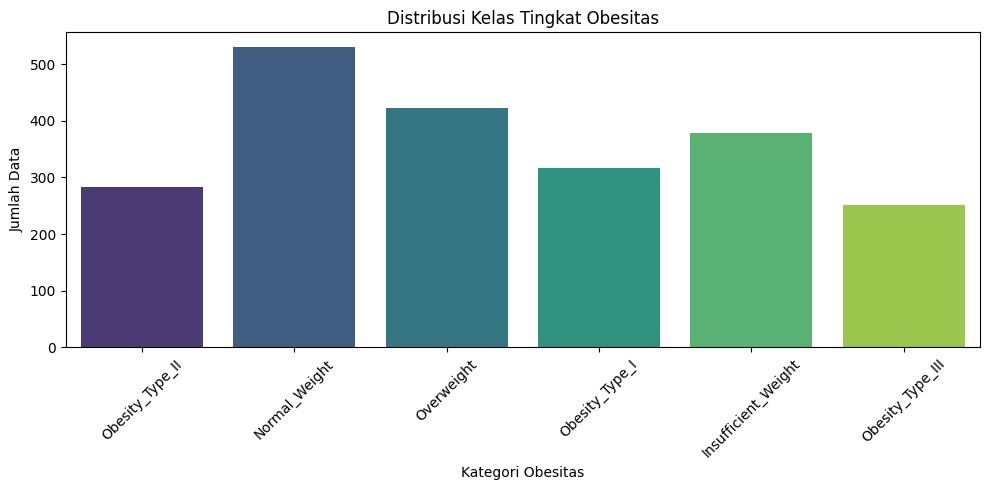


KATEGORI                  | JUMLAH   | Perhitungan Rasio | RASIO    | STATUS
------------------------------------------------------------------------------------------
Normal_Weight             | 530      | 530 / 530         | 1.00     | Seimbang
Overweight                | 423      | 530 / 423         | 1.25     | Seimbang
Insufficient_Weight       | 378      | 530 / 378         | 1.40     | Seimbang
Obesity_Type_I            | 317      | 530 / 317         | 1.67     | Tidak seimbang
Obesity_Type_II           | 283      | 530 / 283         | 1.87     | Tidak seimbang
Obesity_Type_III          | 251      | 530 / 251         | 2.11     | Tidak seimbang


In [24]:
# Visualisasi Diagram Batang
plt.figure(figsize=(10, 5))
sns.countplot(x='Obesity level', data=data, palette='viridis')
plt.title('Distribusi Kelas Tingkat Obesitas')
plt.xlabel('Kategori Obesitas')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tabel imbalance ratio
print("\n" + "="*90)
print(f"{'KATEGORI':<25} | {'JUMLAH':<8} | {'Perhitungan Rasio':<15} | {'RASIO':<8} | {'STATUS'}")
print("-" * 90)

# target jumlah kelas terbanyak
jumlah_terbanyak = data['Obesity level'].value_counts().max()

for kategori, jumlah in data['Obesity level'].value_counts().items():
    rasio = jumlah_terbanyak / jumlah
    status = "Tidak seimbang" if rasio > 1.5 else "Seimbang"
    print(f"{kategori:<25} | {jumlah:<8} | {jumlah_terbanyak} / {jumlah:<11} | {rasio:<8.2f} | {status}")
print("="*90)

## PREPROCESSING DATA

In [25]:
# . Label Encoding
label_mappings = {
    "Gender": {"Female": 0, "Male": 1},
    "Family history of overweight": {"No": 0, "Yes": 1},
    "High caloric food consumption": {"No": 0, "Yes": 1},
    "Smoking": {"No": 0, "Yes": 1},
    "Monitor calories": {"No": 0, "Yes": 1}
}
for col, mapping in label_mappings.items():
    data[col] = data[col].map(mapping)

# Ordinal Encoding
ordinal_mappings = {
    "Vegetable consumption frequency": {"Never": 0, "Sometimes": 1, "Always": 2},
    "Daily main meals frequency": {"Between 1-2": 0, "Three": 1, "More than Three": 2},
    "Between-meal food consumption frequency": {"No": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "Alcohol intake": {"I do not drink": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "Daily water intake": {"Less than a liter": 0, "Between 1 and 2 L": 1, "More than 2 L": 2},
    "Physical exercise": {"I do not have": 0, "1 or 2 days": 1, "2 or 4 days": 2, "4 or 5 days": 3, "Almost Everyday": 4},
    "Daily device usage duration": {"0-2 hours": 0, "3-5 hours": 1, "More than 5 hours": 2},
    "Mode of transportation": {"Walking": 0, "Bike": 1, "Rickshaw": 2, "Public Transportation": 3, "Private Car": 4},
    "Obesity level": {"Insufficient_Weight": 0, "Normal_Weight": 1, "Overweight": 2, "Obesity_Type_I": 3, "Obesity_Type_II": 4, "Obesity_Type_III": 5}
}
for col, mapping in ordinal_mappings.items():
    data[col] = data[col].map(mapping)

display(data.head())

,Gender,Age,Height (m),Weight (kg),Family history of overweight,High caloric food consumption,Vegetable consumption frequency,Daily main meals frequency,Between-meal food consumption frequency,Smoking,Alcohol intake,Daily water intake,Monitor calories,Physical exercise,Daily device usage duration,Mode of transportation,Obesity level
0,1,29,1.65,101.0,1,1,1,1,2,0,0,1,0,0,2,4,4
1,0,25,1.65,53.0,0,0,2,1,3,0,0,1,0,4,2,3,1
2,1,23,1.70,70.0,0,0,2,0,1,1,1,0,0,0,2,3,1
3,1,22,1.68,112.0,1,1,1,1,2,0,0,1,0,0,2,3,4
4,1,19,1.75,67.0,0,1,2,1,1,1,0,1,0,2,1,1,1


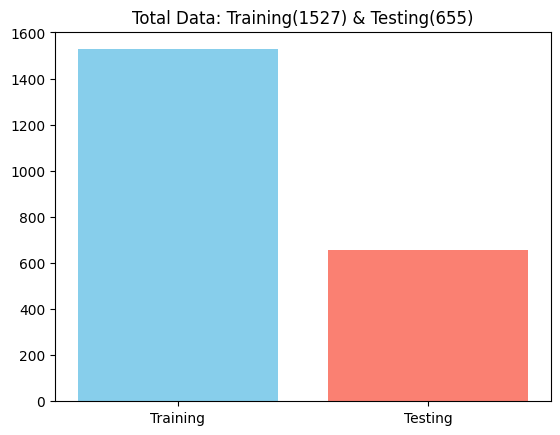

Total Training: 1527
Total Testing: 655


In [26]:
X = data.drop("Obesity level", axis=1)
y = data["Obesity level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# diagram
counts = [len(X_train), len(X_test)]
plt.bar(['Training', 'Testing'], counts, color=['skyblue', 'salmon'])
plt.title(f"Total Data: Training({counts[0]}) & Testing({counts[1]})")
plt.show()

print(f"Total Training: {counts[0]}")
print(f"Total Testing: {counts[1]}")

C:\Users\hp\AppData\Local\Temp\ipykernel_2700\2747682895.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
C:\Users\hp\AppData\Local\Temp\ipykernel_2700\2747682895.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='viridis')


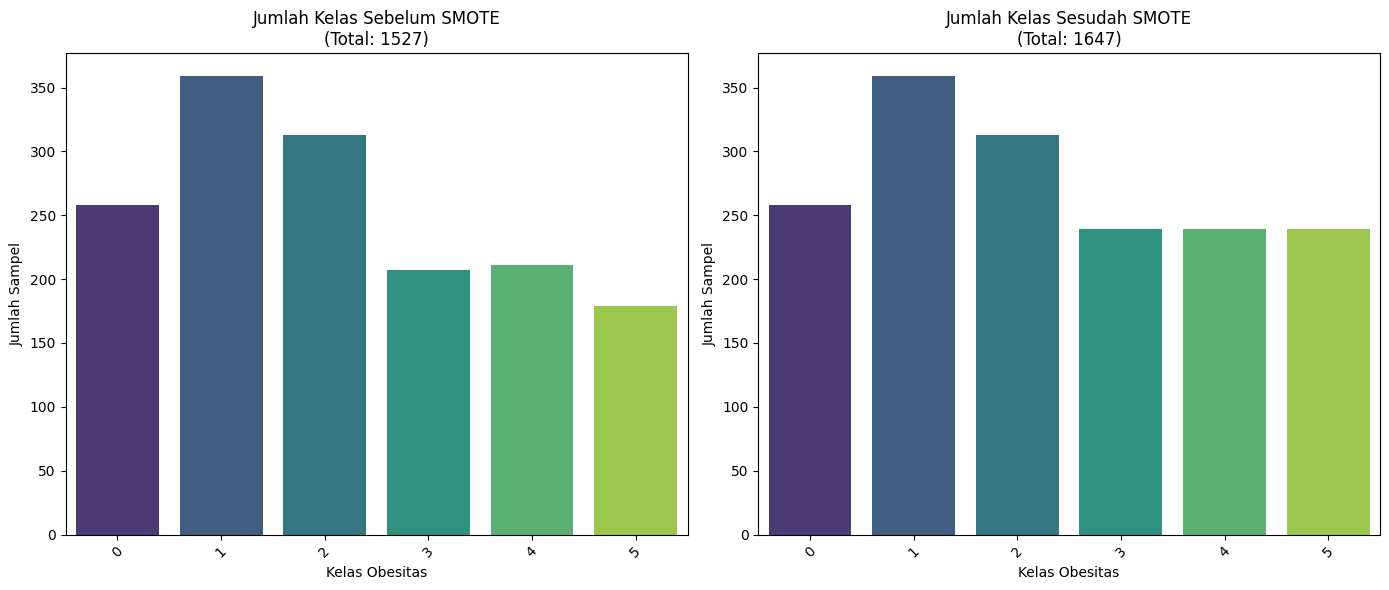

DETAIL PERUBAHAN JUMLAH DATA SETIAP KELAS

[SEBELUM SMOTE]
Kelas 0                    | Jumlah: 258      | Rasio: 1.39    
Kelas 1                    | Jumlah: 359      | Rasio: 1.00    
Kelas 2                    | Jumlah: 313      | Rasio: 1.15    
Kelas 3                    | Jumlah: 207      | Rasio: 1.73    
Kelas 4                    | Jumlah: 211      | Rasio: 1.70    
Kelas 5                    | Jumlah: 179      | Rasio: 2.01    

[SESUDAH SMOTE]
Kelas 0                    | Jumlah: 258      | Rasio: 1.39    
Kelas 1                    | Jumlah: 359      | Rasio: 1.00    
Kelas 2                    | Jumlah: 313      | Rasio: 1.15    
Kelas 3                    | Jumlah: 239      | Rasio: 1.50    
Kelas 4                    | Jumlah: 239      | Rasio: 1.50    
Kelas 5                    | Jumlah: 239      | Rasio: 1.50    
--------------------------------------------------
Data Testing (Tetap Asli): 655


In [27]:
# jumlah kelas mayoritas
jumlah_terbanyak = pd.Series(y_train).value_counts().max()

# kelas yang akan di-oversample untuk mencapai rasio < 1.5
sampling_strategy = {}

for kategori, jumlah in pd.Series(y_train).value_counts().items():
    rasio = jumlah_terbanyak / jumlah
    # penambahkan data untuk kelas yang rasio lebih besar dari 1.5
    if rasio > 1.5:
        target_oversample = int(jumlah_terbanyak / 1.5)  # Coba capai rasio 1.5
        sampling_strategy[kategori] = target_oversample

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Visualisasi
plt.figure(figsize=(14, 6))

# Sebelum smote
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title(f'Jumlah Kelas Sebelum SMOTE\n(Total: {len(y_train)})')
plt.xticks(rotation=45)
plt.xlabel('Kelas Obesitas')
plt.ylabel('Jumlah Sampel')

# Sesudah smote
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_res, palette='viridis')
plt.title(f'Jumlah Kelas Sesudah SMOTE\n(Total: {len(y_train_res)})')
plt.xticks(rotation=45)
plt.xlabel('Kelas Obesitas')
plt.ylabel('Jumlah Sampel')

plt.tight_layout()
plt.show()

# Detail jumlah data
print("="*50)
print("DETAIL PERUBAHAN JUMLAH DATA SETIAP KELAS")
print("="*50)

# Sebelum SMOTE: Tambahkan rasio
print("\n[SEBELUM SMOTE]")
before_smote_counts = pd.Series(y_train).value_counts().sort_index()
for kategori, jumlah in before_smote_counts.items():
    rasio = jumlah_terbanyak / jumlah
    print(f"Kelas {kategori:<20} | Jumlah: {jumlah:<8} | Rasio: {rasio:<8.2f}")

# Setelah SMOTE: Tambahkan rasio
print("\n[SESUDAH SMOTE]")
after_smote_counts = pd.Series(y_train_res).value_counts().sort_index()
for kategori, jumlah in after_smote_counts.items():
    rasio = jumlah_terbanyak / jumlah
    print(f"Kelas {kategori:<20} | Jumlah: {jumlah:<8} | Rasio: {rasio:<8.2f}")

print("-" * 50)
print(f"Data Testing (Tetap Asli): {X_test.shape[0]}")

In [28]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_base, X_train_res, y_train_res, cv=cv)

print(f"Hasil Akurasi tiap Fold: \n{cv_scores}")
print(f"\nRata-rata Akurasi Training (CV): {cv_scores.mean()*100:.2f}%")


Hasil Akurasi tiap Fold: 
[0.89090909 0.8969697  0.86666667 0.93333333 0.9030303  0.87272727
 0.81818182 0.87804878 0.87804878 0.81097561]

Rata-rata Akurasi Training (CV): 87.49%


Akurasi Final pada Data Testing: 86.41%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       120
           1       0.84      0.86      0.85       171
           2       0.76      0.83      0.79       110
           3       0.86      0.81      0.84       110
           4       0.89      0.89      0.89        72
           5       0.97      0.92      0.94        72

    accuracy                           0.86       655
   macro avg       0.88      0.87      0.87       655
weighted avg       0.87      0.86      0.86       655



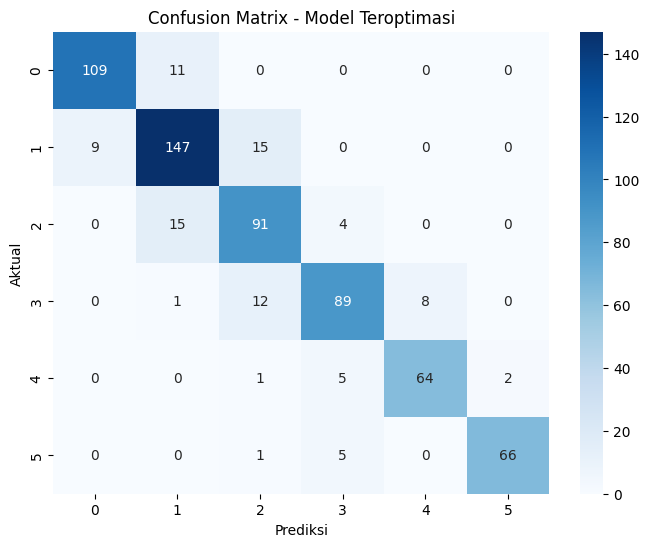

In [29]:
rf_base.fit(X_train_res, y_train_res)
y_pred_best = rf_base.predict(X_test)

print(f"Akurasi Final pada Data Testing: {accuracy_score(y_test, y_pred_best)*100:.2f}%")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_best))

# Visualisasi Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Model Teroptimasi')
plt.show()

In [30]:
import pickle

with open('rf_model_skenario1.pkl', 'wb') as file:
    pickle.dump(rf_base, file)